In [37]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)


In [38]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import Image, display

import synthetic.scripts.different_vars as dv

# Reload so notebook changes pick up the latest script version and current baselines.
dv = importlib.reload(dv)


In [39]:
# Notebook controls. These override the defaults in synthetic/scripts/different_vars.py.
LOAD = True  # Set to False to rerun from the notebook.
SAVE = False
N_CPUS = dv.N_CPUS
JOBLIB_VERBOSE = dv.JOBLIB_VERBOSE

N_DAGS = dv.N_DAGS
THR = dv.THR
VERB = dv.VERB
VAR_VALUES = dv.VAR_VALUES
BASE_DATA_PARAMS = dv.BASE_DATA_PARAMS.copy()
HETERO_VAR_RANGE = dv.HETERO_VAR_RANGE
JOINT_AGGS = dv.JOINT_AGGS
SELECTED_EXPERIMENT_LEGS = dv.SELECTED_EXPERIMENT_LEGS
SKIP_IDX = []  # Example: [2, 5] skips DAGMA and CoLiDE-NV.

# Push notebook controls back into the script module used below.
dv.LOAD = LOAD
dv.SAVE = SAVE
dv.N_CPUS = N_CPUS
dv.JOBLIB_VERBOSE = JOBLIB_VERBOSE
dv.HETERO_VAR_RANGE = HETERO_VAR_RANGE
dv.SKIP_IDX = SKIP_IDX


In [40]:
def display_png(path):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing figure: {path}")


def display_scenario_figures(suffix):
    display_png(Path(dv.PATH) / f"vars_{suffix}_summary_mean.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_summary_median.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_all_metrics_mean.png")
    display_png(Path(dv.PATH) / f"vars_{suffix}_all_metrics_median.png")


def display_joint_figures(aggs=JOINT_AGGS):
    for agg in aggs:
        display_png(Path(dv.PATH) / f"vars_hom_hetero_joint_{agg}.png")


def scenario_result(scenario, metrics, exps, var_values):
    return {
        "scenario": scenario,
        "metrics": metrics,
        "exps": exps,
        "var_values": var_values,
    }


def metric_summary(metrics, exps, var_values):
    shd, _, _, _, err, acyc, runtime, _ = metrics
    rows = []
    for j, exp in enumerate(exps):
        for i, var in enumerate(var_values):
            rows.append({
                "variance": var,
                "method": exp["leg"],
                "err_mean": np.mean(err[:, i, j]),
                "err_median": np.median(err[:, i, j]),
                "shd_mean": np.mean(shd[:, i, j]),
                "shd_median": np.median(shd[:, i, j]),
                "acyc_mean": np.mean(acyc[:, i, j]),
                "time_mean": np.mean(runtime[:, i, j]),
            })
    return pd.DataFrame(rows)


In [41]:
Exps = dv.filter_experiments(dv.build_experiments(), SELECTED_EXPERIMENT_LEGS)
vars = np.asarray(VAR_VALUES)
scenarios = dv.build_scenarios(BASE_DATA_PARAMS)

hom_scenario = scenarios[0]
hetero_scenario = scenarios[1]

print("Scenarios:", [scenario["name"] for scenario in scenarios])
print("Baselines:")
for i, exp in enumerate(Exps):
    skipped = " (skipped)" if i in SKIP_IDX else ""
    print(f"  {i}: {exp['leg']}{skipped}")
print("Variance grid:", vars)
print("Mode:", "load" if LOAD else "run")


Scenarios: ['homocedastic', 'heterocedastic']
Baselines:
  0: NOMAD-adam
  1: NOMAD-fista
  2: DAGMA
  3: NonDAGMA
  4: CoLiDE-EV
  5: CoLiDE-NV
Variance grid: [ 1  5 10 20 30]
Mode: load


## Homocedastic Scenario


Loaded variance results from /home/srey/Investigacion/cvx_dag_learning/results/var/var_hom_ERgraph_4N.npz


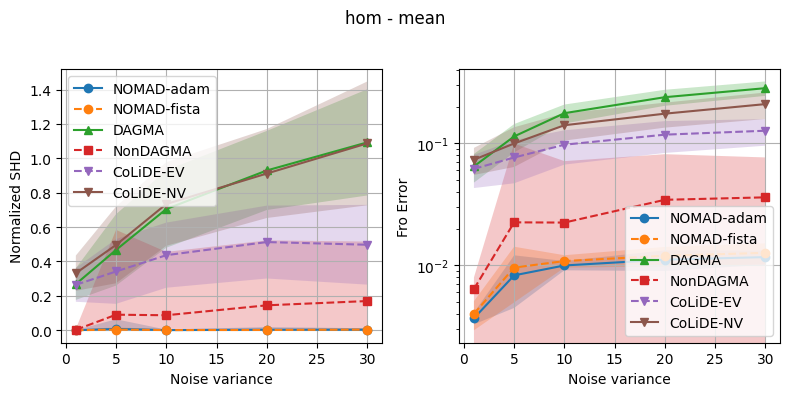

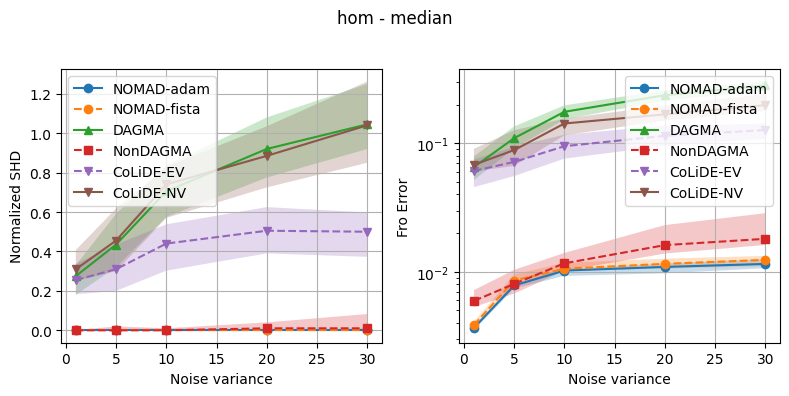

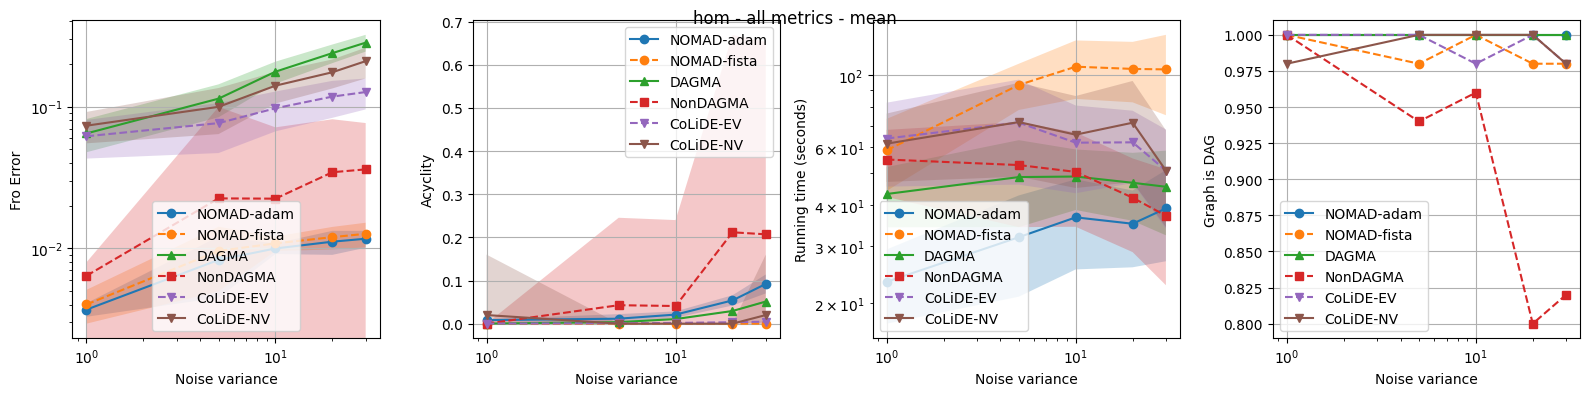

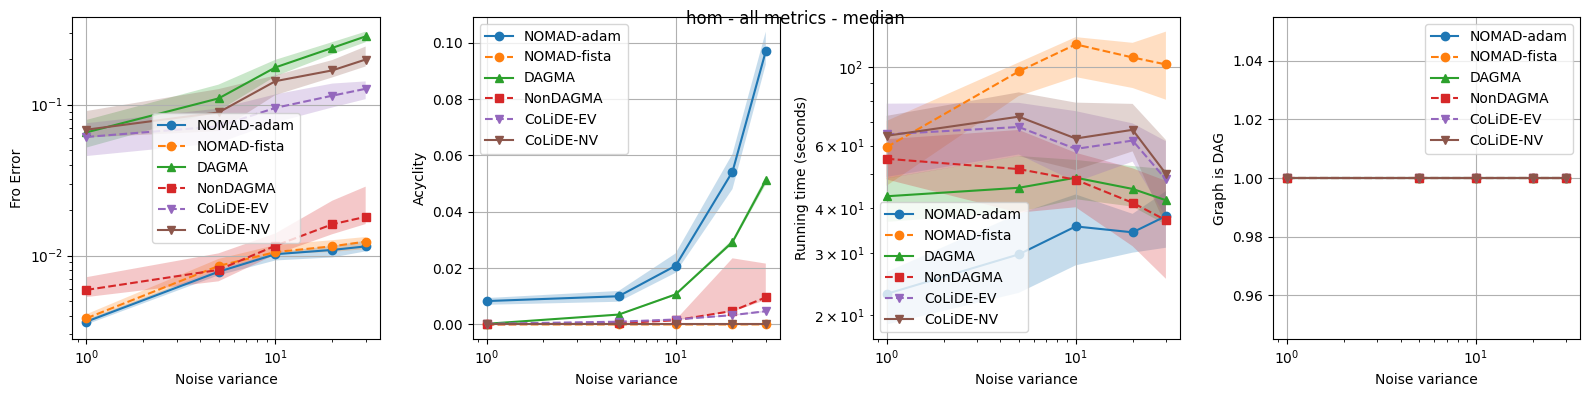

In [42]:
*hom_metrics, hom_exps, hom_vars = dv.run_or_load_vars_results(
    hom_scenario,
    vars,
    Exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

dv.plot_results(hom_metrics, hom_exps, hom_vars, hom_scenario["suffix"], skip_idx=SKIP_IDX)
hom_result = scenario_result(hom_scenario, hom_metrics, hom_exps, hom_vars)

display_scenario_figures(hom_scenario["suffix"])


## Heterocedastic Scenario


Loaded variance results from /home/srey/Investigacion/cvx_dag_learning/results/var/var_hetero_ERgraph_4N.npz


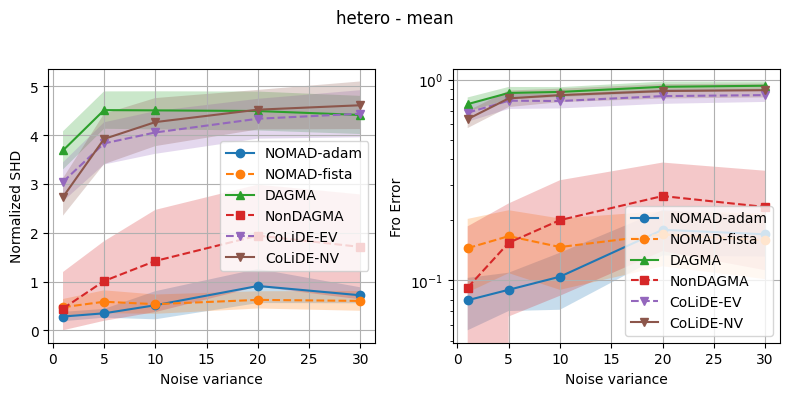

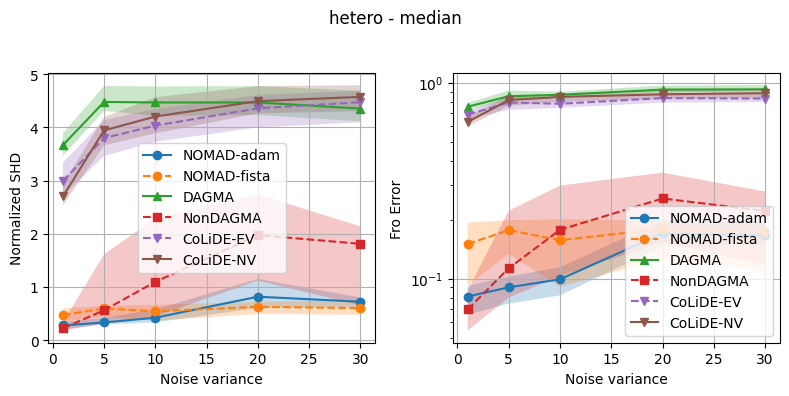

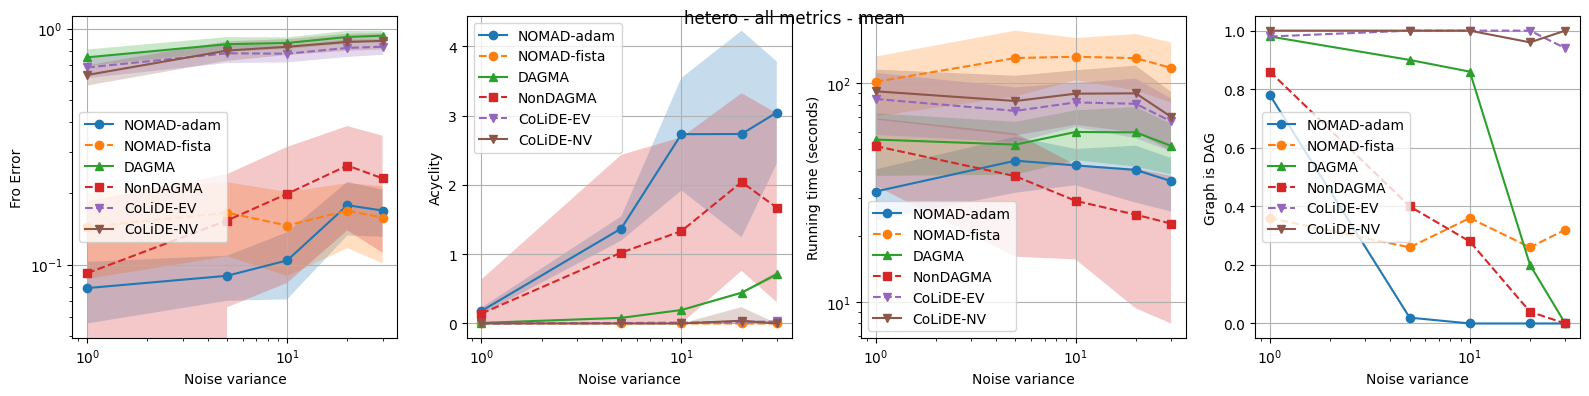

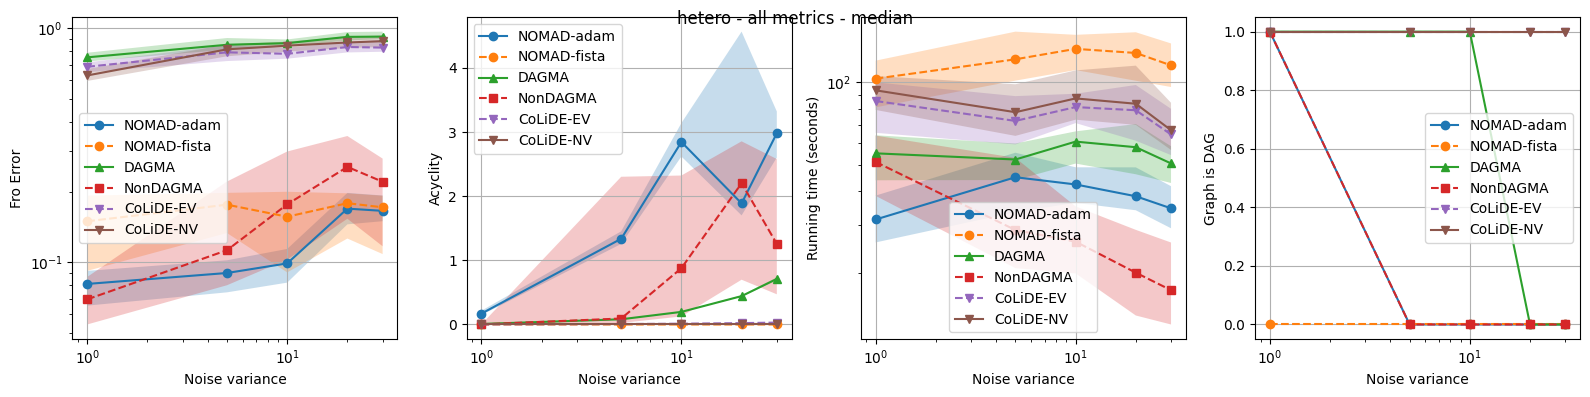

In [43]:
*hetero_metrics, hetero_exps, hetero_vars = dv.run_or_load_vars_results(
    hetero_scenario,
    vars,
    Exps,
    N_DAGS,
    thr=THR,
    verb=VERB,
)

dv.plot_results(hetero_metrics, hetero_exps, hetero_vars, hetero_scenario["suffix"], skip_idx=SKIP_IDX)
hetero_result = scenario_result(hetero_scenario, hetero_metrics, hetero_exps, hetero_vars)

display_scenario_figures(hetero_scenario["suffix"])


## Joint Figures


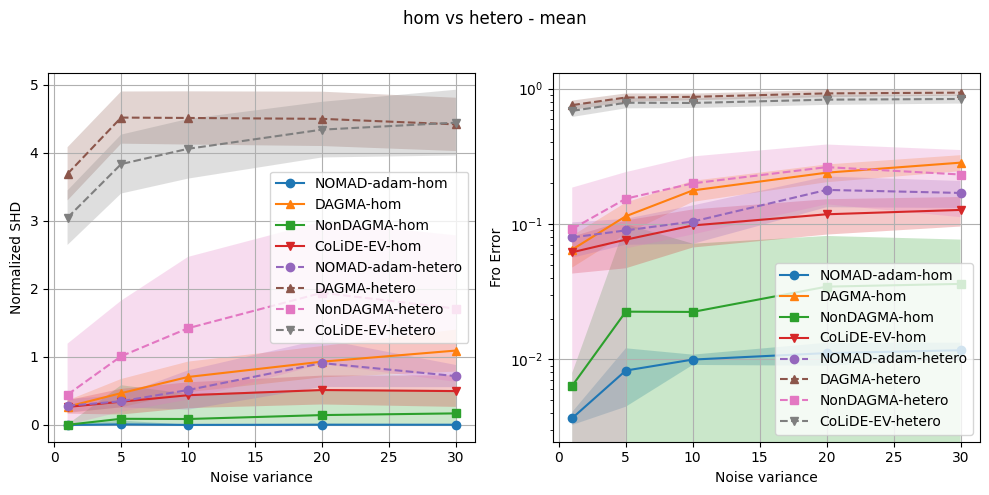

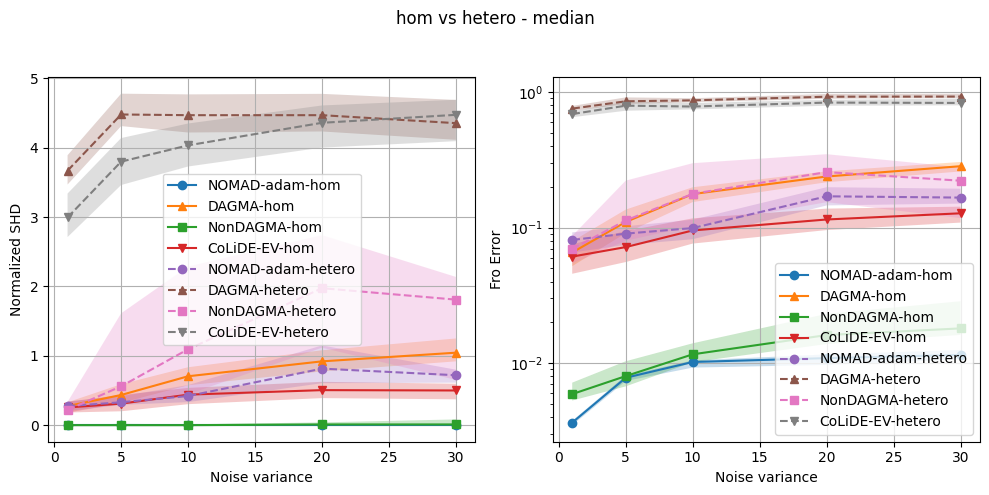

In [46]:
scenario_results = [hom_result, hetero_result]

SKIP_IDX = [1,5,7,11]

for agg in JOINT_AGGS:
    dv.plot_joint_results(scenario_results, agg=agg, skip_idx=SKIP_IDX)

display_joint_figures(JOINT_AGGS)


## Optional Tables


In [45]:
hom_summary = metric_summary(hom_metrics, hom_exps, hom_vars)
hetero_summary = metric_summary(hetero_metrics, hetero_exps, hetero_vars)

display(hom_summary)
display(hetero_summary)


,variance,method,err_mean,err_median,shd_mean,shd_median,acyc_mean,time_mean
0,1,NOMAD-adam,0.003680,0.003649,0.0002,0.000,0.008299,23.267173
1,5,NOMAD-adam,0.008265,0.007813,0.0080,0.000,0.011557,31.862465
2,10,NOMAD-adam,0.009959,0.010209,0.0010,0.000,0.021079,36.651574
3,20,NOMAD-adam,0.011118,0.010899,0.0034,0.000,0.053919,35.034396
4,30,NOMAD-adam,0.011667,0.011499,0.0034,0.000,0.092048,39.033029
5,1,NOMAD-fista,0.004002,0.003841,0.0004,0.000,0.000028,58.806998
6,5,NOMAD-fista,0.009573,0.008536,0.0038,0.000,0.000031,93.266451
7,10,NOMAD-fista,0.010818,0.010549,0.0012,0.000,0.000039,106.110289
8,20,NOMAD-fista,0.011965,0.011519,0.0018,0.000,0.000035,104.462674
9,30,NOMAD-fista,0.012639,0.012369,0.0038,0.000,0.000070,104.094132


,variance,method,err_mean,err_median,shd_mean,shd_median,acyc_mean,time_mean
0,1,NOMAD-adam,0.079480,0.080962,0.2818,0.275,0.181107,32.064226
1,5,NOMAD-adam,0.089600,0.090172,0.3482,0.330,1.371055,44.362446
2,10,NOMAD-adam,0.104128,0.099117,0.5134,0.420,2.733275,42.207355
3,20,NOMAD-adam,0.178364,0.169886,0.9084,0.815,2.736026,40.238581
4,30,NOMAD-adam,0.169366,0.166205,0.7176,0.720,3.046240,35.797691
5,1,NOMAD-fista,0.144477,0.149999,0.4730,0.470,0.000022,101.721963
6,5,NOMAD-fista,0.165845,0.176632,0.5850,0.595,0.000037,130.697087
7,10,NOMAD-fista,0.146314,0.156892,0.5356,0.540,0.000050,132.443262
8,20,NOMAD-fista,0.169199,0.179220,0.6234,0.625,0.000054,130.489735
9,30,NOMAD-fista,0.158111,0.172100,0.6026,0.600,0.000033,117.775801
